We aim to Keep recall ≈ target over time by re-tuning the threshold on a small labeled window of each new batch, then evaluate recall stability vs. using the fixed CP-1 threshold.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from src.preprocessing import AmountTimeScaler, split_X_y
from src.utils import threshold_for_target_recall, summarize

DATA_PROCESSED = Path("../data/processed")
b1 = pd.read_csv(DATA_PROCESSED/"batch1_train.csv")
b2 = pd.read_csv(DATA_PROCESSED/"batch2_test.csv")
b3 = pd.read_csv(DATA_PROCESSED/"batch3_stream.csv")
b4 = pd.read_csv(DATA_PROCESSED/"batch4_stream.csv")
TARGET_RECALL = 0.80


In [3]:
X, y = split_X_y(b1)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipe = Pipeline([("scaler", AmountTimeScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
pipe.fit(X_tr, y_tr)
thr_fixed = threshold_for_target_recall(y_val, pipe.predict_proba(X_val)[:,1], TARGET_RECALL)
thr_fixed


0.00105131323229303

In [4]:
def eval_batch(df, thr):
    X_b, y_b = split_X_y(df)
    score_b = pipe.predict_proba(X_b)[:,1]
    return summarize(y_b, score_b, thr)

baseline = []
for df,label in [(b2,"TEST"),(b3,"S1"),(b4,"S2")]:
    baseline.append(eval_batch(df, thr_fixed).assign(batch=label, mode="fixed_threshold"))
baseline = pd.concat(baseline, ignore_index=True)
baseline


,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,mode
0,0.001051,0.216374,0.787234,0.339450,0.368661,37,134,9819,10,171,0.0171,TEST,fixed_threshold
1,0.001051,0.072289,0.666667,0.130435,0.347861,6,77,9914,3,83,0.0083,S1,fixed_threshold
2,0.001051,0.133333,1.000000,0.235294,0.662630,10,65,9925,0,75,0.0075,S2,fixed_threshold


In [6]:
def recalibrate_and_eval(df, label, window_frac=0.2):
    X_b, y_b = split_X_y(df)
    n = len(y_b)
    n_win = max(1, int(window_frac*n))
    X_win, y_win = X_b.iloc[:n_win], y_b[:n_win]  # simulate 'recent labeled cases'
    thr_new = threshold_for_target_recall(y_win, pipe.predict_proba(X_win)[:,1], TARGET_RECALL)
    return eval_batch(df, thr_new).assign(batch=label, mode="adaptive", window_frac=window_frac, thr_new=thr_new)

adaptive = pd.concat([
    recalibrate_and_eval(b2, "TEST"),
    recalibrate_and_eval(b3, "S1"),
    recalibrate_and_eval(b4, "S2")
], ignore_index=True)

pd.concat([baseline, adaptive], ignore_index=True)


,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,mode,window_frac,thr_new
0,0.001051,0.216374,0.787234,0.339450,0.368661,37,134,9819,10,171,0.0171,TEST,fixed_threshold,NaN,NaN
1,0.001051,0.072289,0.666667,0.130435,0.347861,6,77,9914,3,83,0.0083,S1,fixed_threshold,NaN,NaN
2,0.001051,0.133333,1.000000,0.235294,0.662630,10,65,9925,0,75,0.0075,S2,fixed_threshold,NaN,NaN
3,0.500000,0.432432,0.680851,0.528926,0.368661,32,42,9911,15,74,0.0074,TEST,adaptive,0.2,0.500000
4,0.500000,0.375000,0.666667,0.480000,0.347861,6,10,9981,3,16,0.0016,S1,adaptive,0.2,0.500000
5,0.001011,0.131579,1.000000,0.232558,0.662630,10,66,9924,0,76,0.0076,S2,adaptive,0.2,0.001011


In [7]:
df_all = pd.concat([baseline, adaptive], ignore_index=True)


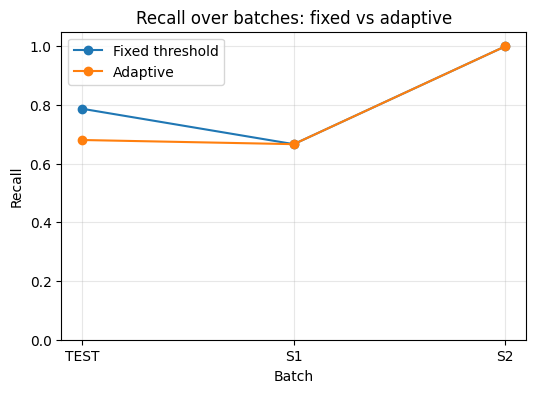

In [8]:
import matplotlib.pyplot as plt


batches = ["TEST", "S1", "S2"]

fixed = df_all[df_all["mode"] == "fixed_threshold"].set_index("batch")
adapt = df_all[df_all["mode"] == "adaptive"].set_index("batch")

plt.figure(figsize=(6,4))
plt.plot(batches, fixed.loc[batches, "recall"], marker="o", label="Fixed threshold")
plt.plot(batches, adapt.loc[batches, "recall"], marker="o", label="Adaptive")
plt.ylim(0, 1.05)
plt.title("Recall over batches: fixed vs adaptive")
plt.xlabel("Batch")
plt.ylabel("Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
